In [45]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

First we will load the dataset


In [46]:
df = pd.read_csv("/Country-data.csv")

print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Now,we will do some basic insprection of this dataset

In [47]:
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [49]:
df.isnull().sum()


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [50]:
#As there is no null values,so we will go forward to check duplicate values
print("Duplicates:", df.duplicated().sum())



Duplicates: 0


Now  we will see the correlation between different coloumns
Correlation Analysis

Correlation analysis helps us understand relationships between variables.


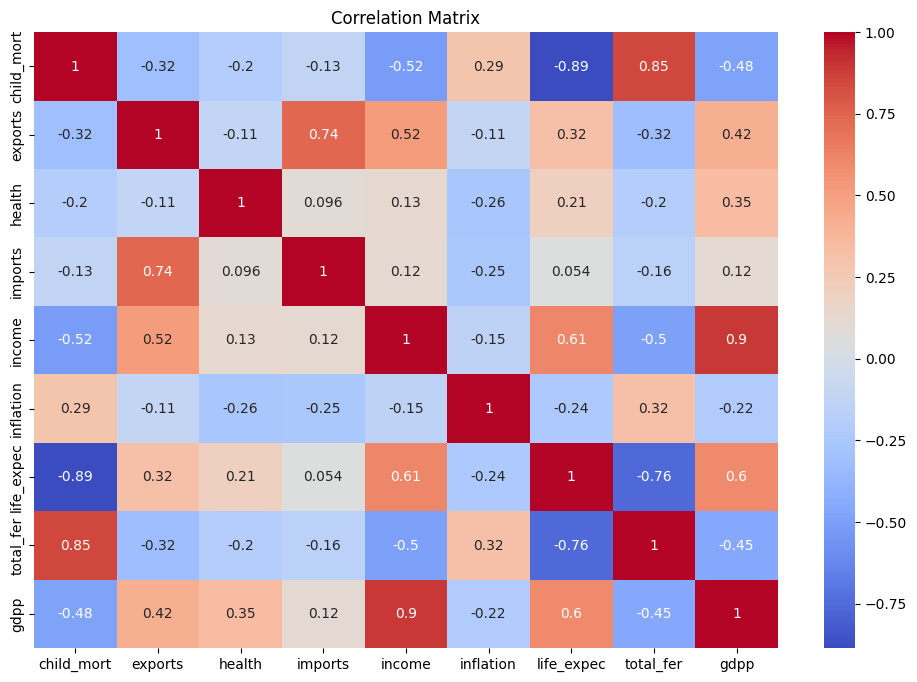

In [51]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Now we will check for the distribution of each feature is essential before applying machine learning algorithms.

Feature Distribution Analysis->
Understanding the distribution of each feature is essential before applying machine learning algorithms.

Using histograms and density plots, we can identify:

- Skewed distributions
- Normal distributions
- Extreme values
- Potential outliers

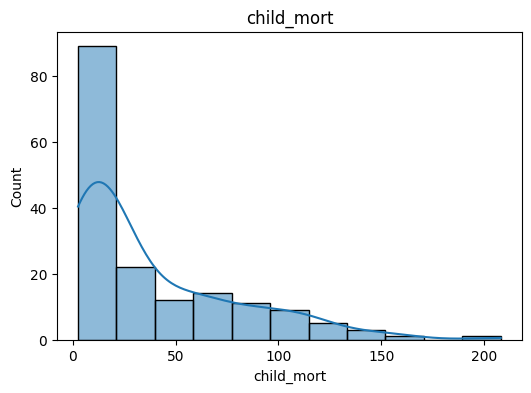

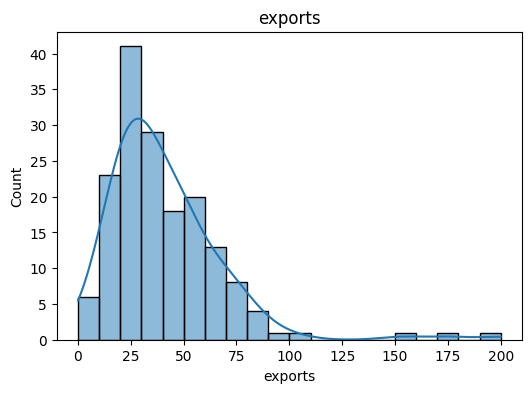

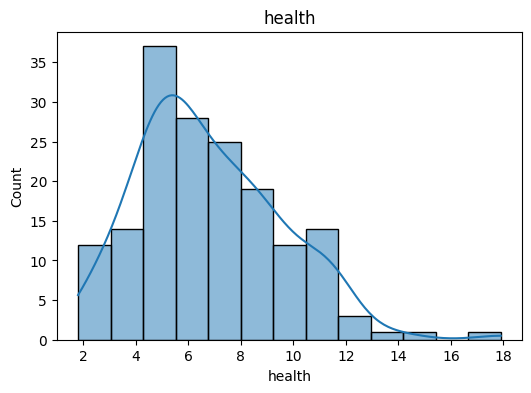

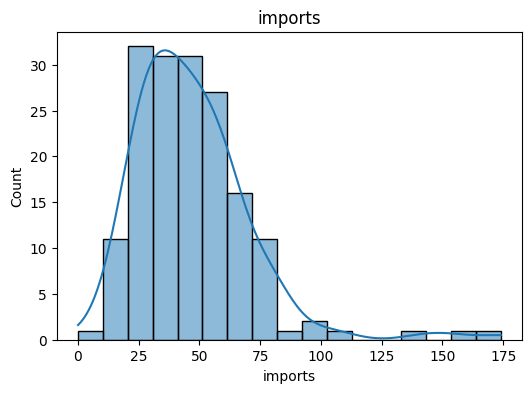

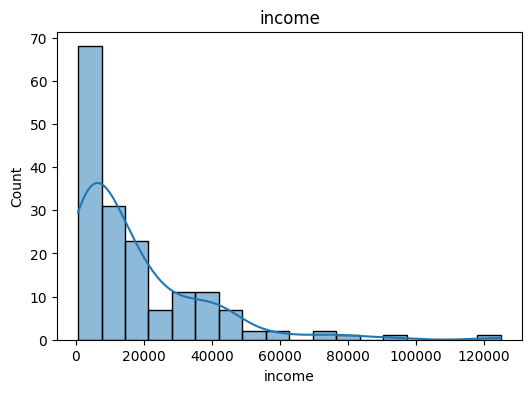

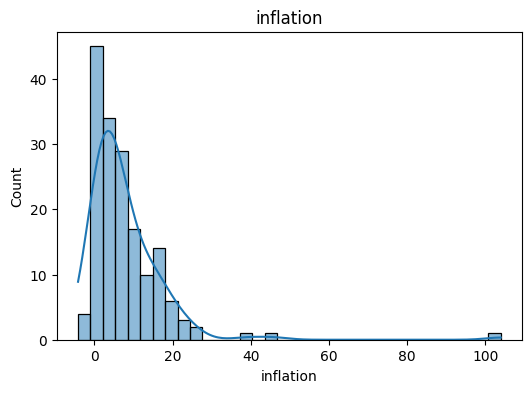

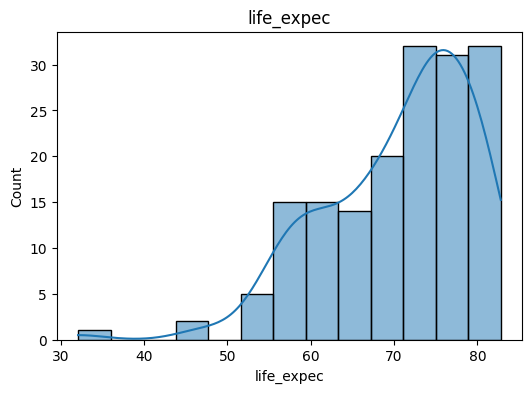

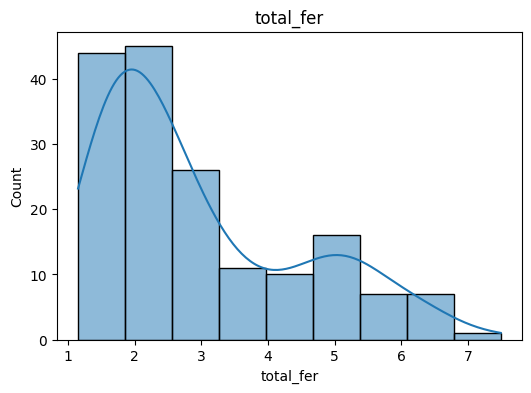

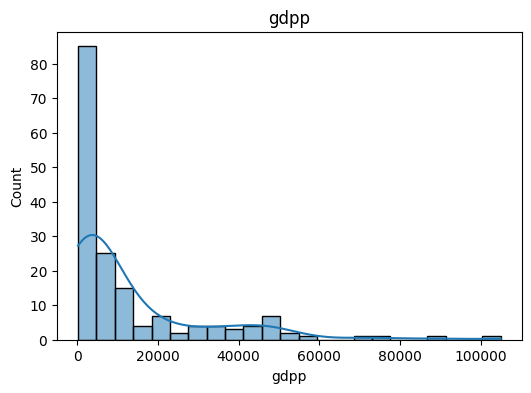

In [52]:
num_cols = df.columns[1:]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Outlier Detection

Outliers are observations that significantly differ from the majority of the data.
Now we will detect the outliers using the boxplot


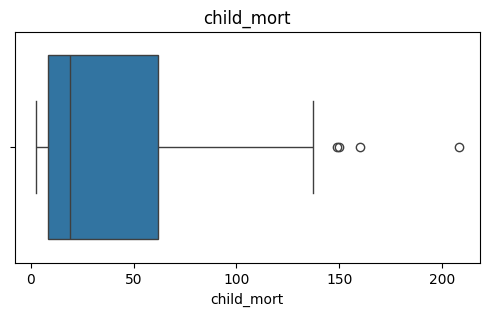

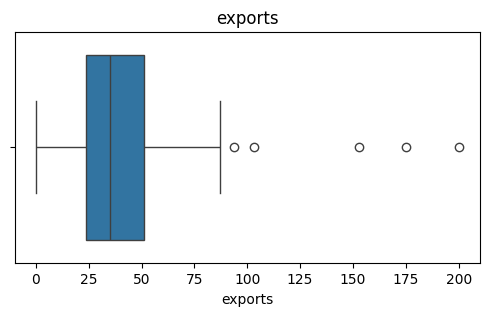

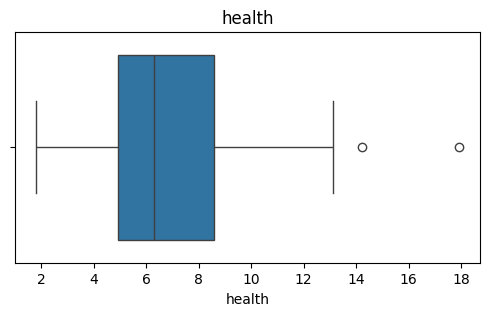

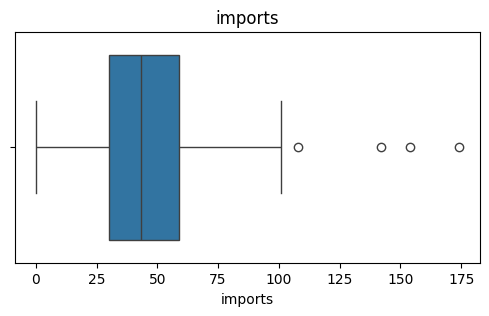

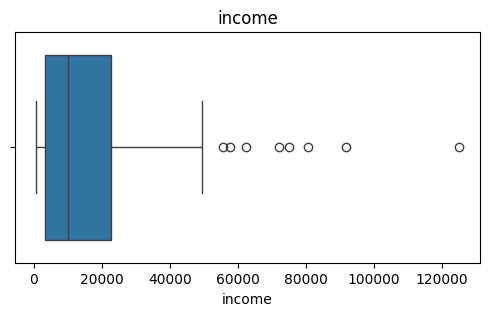

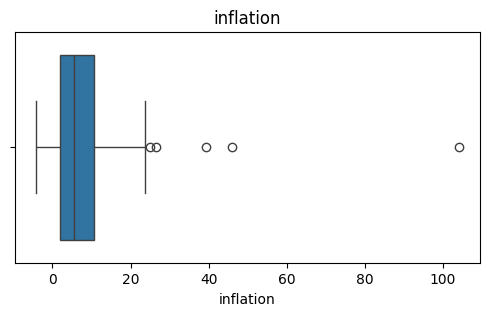

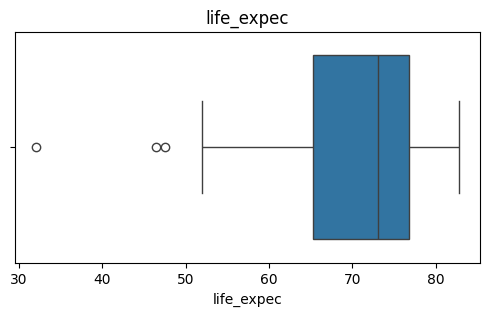

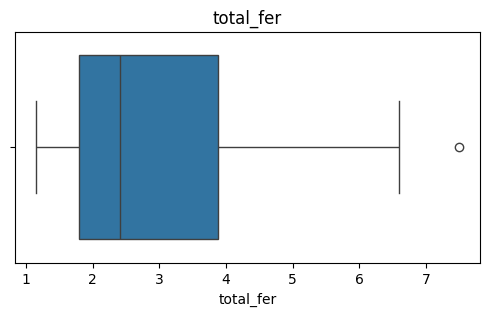

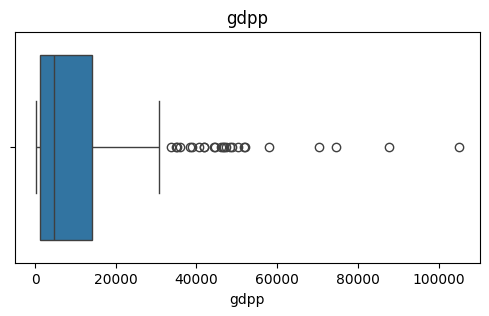

In [53]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

 Feature Scaling

The dataset contains features measured on different scales.



In [54]:
X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


 Determining the Optimal Number of Clusters

K-Means requires us to specify the number of clusters beforehand.

To identify the most appropriate value of K, we use the Elbow Method.

In [55]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

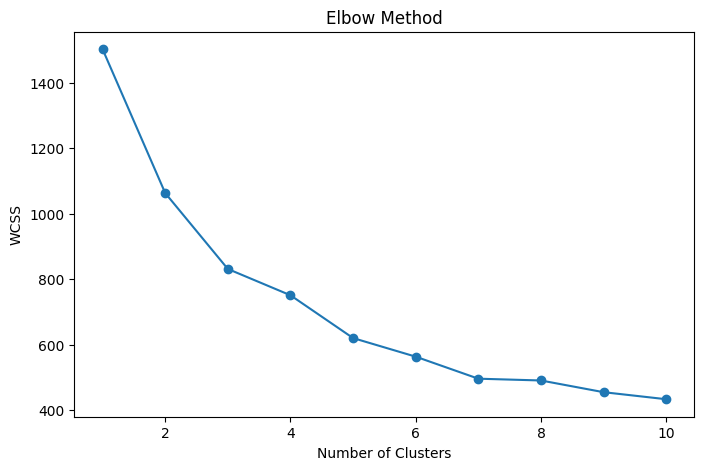

In [56]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


K-Means Clustering

K-Means is an unsupervised machine learning algorithm used to group similar observations together.

The objective is to segment countries into clusters based on their socio-economic and health indicators.
Here we are taking value of (K=3),as we are assuming the numbers of cluster as 3

In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

count of cluster

In [58]:
df["Cluster"].value_counts()

,count
Cluster,
0,86
2,45
1,36


Cluster Interpretation

Creating clusters is only the first step.

To understand what each cluster represents, we will analyze the average feature values within each group.


In [59]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


Dimensionality Reduction using PCA

The dataset contains multiple numerical dimensions that are difficult to visualize directly.

Principal Component Analysis (PCA) reduces the dimensionality of the dataset while preserving most of the important information.

In [60]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [61]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

Visualizing Country Clusters

Using the principal components generated by PCA, we can plot countries in a two-dimensional space.

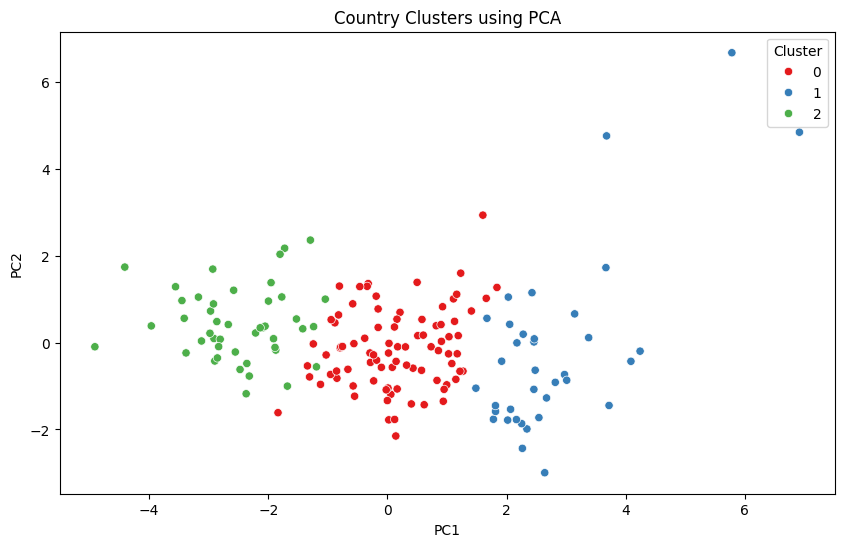

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("Country Clusters using PCA")

plt.show()

Density-Based Clustering using DBSCAN

Unlike K-Means, DBSCAN does not require a predefined number of clusters.

DBSCAN identifies:

- Dense regions of similar observations
- Noise points
- Outliers

In [63]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

In [64]:
df["DBSCAN_Cluster"].value_counts()
# The countries that have values as -1 are referred as outliers

,count
DBSCAN_Cluster,
0,137
-1,30


Identifying Outlier Countries

Countries identified as noise points by DBSCAN may have significantly different characteristics compared to the rest of the dataset.




In [65]:
outliers = df[df["DBSCAN_Cluster"] == -1]

outliers[["country"]]

,country
3,Angola
23,Brunei
31,Central African Republic
37,"Congo, Dem. Rep."
38,"Congo, Rep."
49,Equatorial Guinea
55,Gabon
66,Haiti
72,Iraq
73,Ireland


Identifying Outlier Countries

Countries identified as noise points by DBSCAN may have significantly different characteristics compared to the rest of the dataset.

In [66]:
X = df.drop(
    ["country", "Cluster", "DBSCAN_Cluster"],
    axis=1
)

y = df["Cluster"]

Preparing Data for Classification

The cluster labels generated by K-Means will now serve as target classes.

We split the dataset into training and testing sets to evaluate the performance of supervised machine learning models.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

In [68]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Random Forest Evaluation

In [69]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)


Accuracy: 0.9705882352941176


In [70]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



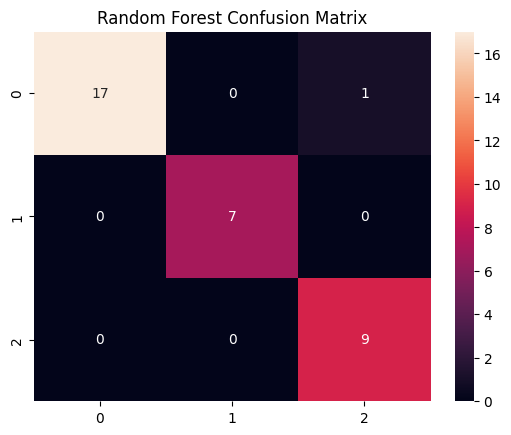

In [71]:
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

XGBoost Classifier

XGBoost is a powerful gradient boosting algorithm that builds trees sequentially.



In [72]:
pip install xgboost

In [73]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


XGBoost Evaluation

In [74]:
print(
    "Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

Accuracy: 0.9705882352941176


In [75]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



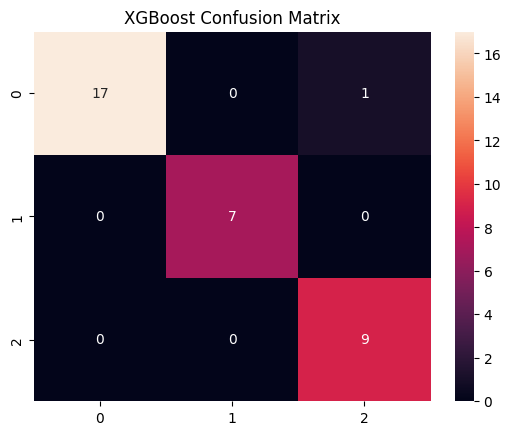

In [76]:
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

Model Evaluation

After training the models, it is important to evaluate their performance.

We will use:

- Accuracy Score
- Classification Report
- Confusion Matrix

These metrics provide insights into the predictive capability of each model.

In [77]:
rf_acc = accuracy_score(y_test, rf_pred)

xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest","XGBoost"],
    "Accuracy": [rf_acc, xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


Feature Importance Analysis

Feature importance helps us understand which socio-economic indicators contribute most to country segmentation.

This analysis provides valuable insights into the factors that influence development patterns across countries.

In [78]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.296120
8,gdpp,0.227301
4,income,0.164629
6,life_expec,0.164469
7,total_fer,0.097647
2,health,0.017380
1,exports,0.011820
5,inflation,0.011761
3,imports,0.008873


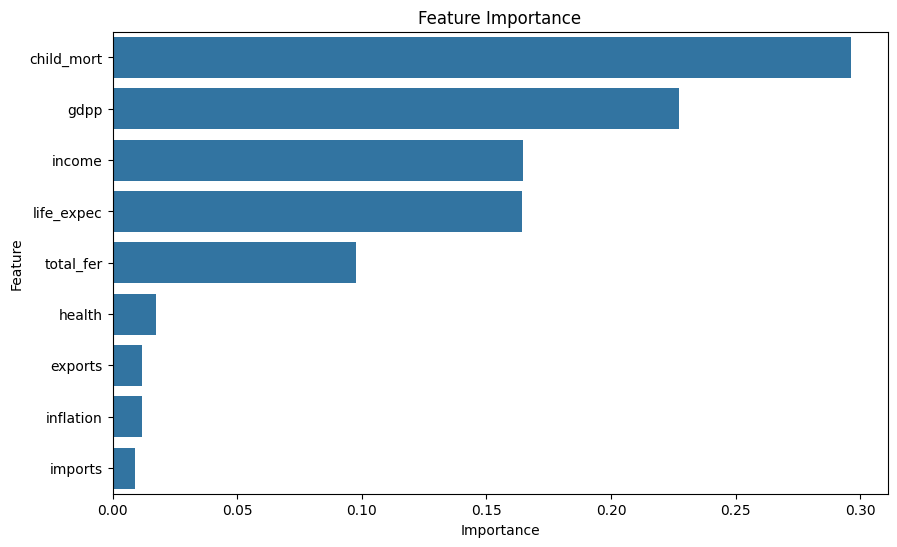

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [80]:
df[df["Cluster"] == 2][
    ["country","income","gdpp","child_mort"]
].head(20)

,country,income,gdpp,child_mort
0,Afghanistan,1610,553,90.2
3,Angola,5900,3530,119.0
17,Benin,1820,758,111.0
25,Burkina Faso,1430,575,116.0
26,Burundi,764,231,93.6
28,Cameroon,2660,1310,108.0
31,Central African Republic,888,446,149.0
32,Chad,1930,897,150.0
36,Comoros,1410,769,88.2
37,"Congo, Dem. Rep.",609,334,116.0


Conclusion

In this project, we applied both unsupervised and supervised machine learning techniques to analyze country-level socio-economic data.

The workflow included:

- Data preprocessing
- Exploratory data analysis
- Country segmentation using K-Means and DBSCAN
- Dimensionality reduction using PCA
- Classification using Random Forest and XGBoost

The resulting Country Intelligence System provides meaningful insights that can support data-driven decision making and aid allocation strategies.